In [ ]:
#########################################################################
########------ Ciencia de Datos e IA Generativa con Python ------########
#########################################################################
# Capacitador: Julio César Bernal Fernández
# email: juliobf08@gmail.com
# Tema : Aplicación de Aprendizaje Supervisado 2.0
# versión: 1.0
#########################################################################

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

#Laboratorio de Aprendizaje Supervisado

#Arbol de Desicion

* criterion: Criterio utilizado para medir la calidad de una división. Puede ser "gini" o "entropy".
* splitter: Estrategia utilizada para elegir la división en cada nodo. Puede ser "best" (elegir la mejor división) o "random" (elegir la mejor división aleatoria).
* max_depth: Profundidad máxima del árbol. Si es None, el árbol se expande hasta que todas las hojas contengan menos de min_samples_split muestras.
* min_samples_split: El número mínimo de muestras requeridas para dividir un nodo interno. Si una hoja contiene menos muestras que este valor, la división no se realiza.
* min_samples_leaf: El número mínimo de muestras requeridas para ser una hoja. Si una hoja contiene menos muestras que este valor, se fusionará con su nodo padre.
* max_features: El número máximo de características a considerar al buscar la mejor división.

2. SEX: Género del cliente (1 = masculino, 2 = femenino).
3. EDUCATION: Nivel educativo del cliente (1 = escuela de posgrado, 2 = universidad, 3 = escuela secundaria, 4 = otros).
4. MARRIAGE: Estado civil del cliente (1 = casado, 2 = soltero, 3 = otros).
5. AGE: Edad del cliente (en años).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargar el conjunto de datos
#url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel('/content/drive/MyDrive/Smart Data/Sesion_13_Supervisado/Feature/default of credit card clients.xls', header=1)

In [ ]:
df = df.rename(columns={'default payment next month': 'default', 'PAY_0': 'PAY_1'})
df = df.drop('ID', axis=1)

In [ ]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
df['default'].mean()

0.2212

#Diccionario De variables

0. ID: Identificación del cliente.
1. LIMIT_BAL: Límite de crédito otorgado por el banco (en dólares taiwaneses).
2. SEX: Género del cliente (1 = masculino, 2 = femenino).
3. EDUCATION: Nivel educativo del cliente (1 = escuela de posgrado, 2 = universidad, 3 = escuela secundaria, 4 = otros).
4. MARRIAGE: Estado civil del cliente (1 = casado, 2 = soltero, 3 = otros).
5. AGE: Edad del cliente (en años).
6. PAY_0: Estado de reembolso en septiembre de 2005 (-1 = pago debidamente efectuado, 1 = retraso en el pago durante un mes, 2 = retraso en el pago durante dos meses, ... 8 = retraso en el pago durante ocho meses, 9 = retraso en el pago durante nueve meses y más).
7. PAY_2: Estado de reembolso en agosto de 2005 (igual que PAY_0).
8. PAY_3: Estado de reembolso en julio de 2005 (igual que PAY_0).
9. PAY_4: Estado de reembolso en junio de 2005 (igual que PAY_0).
10. PAY_5: Estado de reembolso en mayo de 2005 (igual que PAY_0).
11. PAY_6: Estado de reembolso en abril de 2005 (igual que PAY_0).
12. BILL_AMT1: Monto del estado de cuenta en septiembre de 2005 (en dólares taiwaneses).
13. BILL_AMT2: Monto del estado de cuenta en agosto de 2005 (en dólares taiwaneses).
14. BILL_AMT3: Monto del estado de cuenta en julio de 2005 (en dólares taiwaneses).
15. BILL_AMT4: Monto del estado de cuenta en junio de 2005 (en dólares taiwaneses).
16. BILL_AMT5: Monto del estado de cuenta en mayo de 2005 (en dólares taiwaneses).
17. BILL_AMT6: Monto del estado de cuenta en abril de 2005 (en dólares taiwaneses).
18. PAY_AMT1: Monto del pago en septiembre de 2005 (en dólares taiwaneses).
19. PAY_AMT2: Monto del pago en agosto de 2005 (en dólares taiwaneses).
20. PAY_AMT3: Monto del pago en julio de 2005 (en dólares taiwaneses).
21. PAY_AMT4: Monto del pago en junio de 2005 (en dólares taiwaneses).
22. PAY_AMT5: Monto del pago en mayo de 2005 (en dólares taiwaneses).
23. PAY_AMT6: Monto del pago en abril de 2005 (en dólares taiwaneses).
24. default.payment.next.month: Indicador de incumplimiento de pago (1 = incumplimiento de pago, 0 = pago puntual).



In [ ]:
# Dividir el conjunto de datos en características y variable objetivo
X = df.drop('default', axis=1)
y = df['default']

In [ ]:
# Dividir el conjunto de datos en conjuntos de entrenamiento y prueba estratificados por el target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
def get_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn+fp)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    gini = 2*auc-1

    return acc, prec, rec, specificity, auc, gini

def train_evaluate_model(train_X, test_X, train_y, test_y, model):
  # Entrena el modelo con los datos de entrenamiento
  model.fit(train_X, train_y)

  # Obtiene las probabilidades y predicciones del conjunto de entrenamiento
  train_y_prob = model.predict_proba(train_X)[:, 1]
  train_y_pred = model.predict(train_X)

  # Obtiene las probabilidades y predicciones del conjunto de prueba
  test_y_prob = model.predict_proba(test_X)[:, 1]
  test_y_pred = model.predict(test_X)

  train_acc, train_prec, train_rec, train_spec, train_auc, train_gini = get_metrics(train_y, train_y_pred, train_y_prob)
  test_acc, test_prec, test_rec, test_spec, test_auc, test_gini = get_metrics(test_y, test_y_pred, test_y_prob)

  print(f"Train Accuracy: {train_acc:.4f}, Precision: {train_prec:.4f}, Recall: {train_rec:.4f}, Specificity: {train_spec:.4f}, AUC: {train_auc:.4f}, Gini: {train_gini:.4f}")
  print(f"Test Accuracy: {test_acc:.4f}, Precision: {test_prec:.4f}, Recall: {test_rec:.4f}, Specificity: {test_spec:.4f}, AUC: {test_auc:.4f}, Gini: {test_gini:.4f}")


In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
X_train_2 = X_train[['SEX','EDUCATION','AGE','MARRIAGE']]
X_test_2 = X_test[['SEX','EDUCATION','AGE','MARRIAGE']]
train_evaluate_model( X_train_2, X_test_2,y_train, y_test,dt_model)

Train Accuracy: 0.7818, Precision: 0.8673, Recall: 0.0160, Specificity: 0.9993, AUC: 0.6260, Gini: 0.2521
Test Accuracy: 0.7770, Precision: 0.3103, Recall: 0.0068, Specificity: 0.9957, AUC: 0.5426, Gini: 0.0852


In [ ]:
import graphviz
from sklearn import tree
dot_data = tree.export_graphviz(dt_model, out_file=None, feature_names=list(X_train_2.columns), class_names=['1','0'], filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("arbol_inicial")  # Guardar la representación gráfica en un archivo
graph.view()

'arbol_inicial.pdf'

In [ ]:
X_train.shape

(24000, 23)

In [ ]:
from itertools import product
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

# Definir los valores que se usarán en la grilla de hiperparámetros
max_depth = [3, 5, 8, 12] # n_vars ** 2
min_samples_split = [100, 200, 300] # 1% , 2% , 3% ... 10%
min_samples_leaf = [50,100, 200, 300] # 0.5% , 1% , 2% ... 5%
max_features = [None, "sqrt", "log2" ,3] #

# Generar todas las combinaciones de hiperparámetros
param_combinations = list(product(max_depth, min_samples_split, min_samples_leaf, max_features))

# Crear listas para almacenar los resultados
gini_train = []
gini_test = []
diff_gini = []

# Iterar sobre todas las combinaciones de hiperparámetros
for params in param_combinations:
    # Crear el modelo con los hiperparámetros actuales
    model = DecisionTreeClassifier(max_depth=params[0], min_samples_split=params[1], min_samples_leaf=params[2], max_features=params[3])

    # Entrenar el modelo
    model.fit(X_train_2, y_train)

    # Calcular el Gini en train
    y_train_prob = model.predict_proba(X_train_2)[:, 1] # PROB(Y = 0) , PROB( Y = 1 )
    gini_train.append(2 * roc_auc_score(y_train, y_train_prob) - 1)

    # Calcular el Gini en test
    y_test_prob = model.predict_proba(X_test_2)[:, 1]
    gini_test.append(2 * roc_auc_score(y_test, y_test_prob) - 1)

    # Calcular la diferencia de Gini entre train y test
    diff_gini.append(gini_train[-1] - gini_test[-1])

# Crear un DataFrame con los resultados
import pandas as pd
results_df = pd.DataFrame({'max_depth': [p[0] for p in param_combinations],
                           'min_samples_split': [p[1] for p in param_combinations],
                           'min_samples_leaf': [p[2] for p in param_combinations],
                           'max_features': [p[3] for p in param_combinations],
                           'gini_train': gini_train,
                           'gini_test': gini_test,
                           'diff_gini': diff_gini})

In [ ]:
results_df

,max_depth,min_samples_split,min_samples_leaf,max_features,gini_train,gini_test,diff_gini
0,3,100,50,None,0.113030,0.094423,0.018607
1,3,100,50,sqrt,0.113010,0.094432,0.018578
2,3,100,50,log2,0.107384,0.090439,0.016946
3,3,100,50,3,0.099036,0.095915,0.003121
4,3,100,100,None,0.112873,0.095173,0.017700
...,...,...,...,...,...,...,...
187,12,300,200,3,0.144143,0.099175,0.044968
188,12,300,300,None,0.157519,0.106050,0.051470
189,12,300,300,sqrt,0.134096,0.104110,0.029987
190,12,300,300,log2,0.151375,0.119286,0.032089


In [ ]:
results_df.to_csv('resultados.csv')

In [ ]:
best_params = {'max_depth' : 12,
'min_samples_split' : 300 ,
'min_samples_leaf' : 300,
'max_features' :3}

In [ ]:
dt_model = DecisionTreeClassifier(**best_params)

In [ ]:
dt_model

In [ ]:
X_train_2 = X_train[['SEX','EDUCATION','AGE','MARRIAGE']]
X_test_2 = X_test[['SEX','EDUCATION','AGE','MARRIAGE']]
train_evaluate_model( X_train_2, X_test_2,y_train, y_test,dt_model)

Train Accuracy: 0.7788, Precision: 0.0000, Recall: 0.0000, Specificity: 1.0000, AUC: 0.5766, Gini: 0.1533
Test Accuracy: 0.7788, Precision: 0.0000, Recall: 0.0000, Specificity: 1.0000, AUC: 0.5571, Gini: 0.1142


In [ ]:
import graphviz
from sklearn import tree
dot_data = tree.export_graphviz(dt_model, out_file=None, feature_names=list(X_train_2.columns), class_names=['1','0'], filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("arbol_final")  # Guardar la representación gráfica en un archivo
graph.view()

'arbol_final.pdf'

In [ ]:
print(dt_model.feature_names_in_,dt_model.feature_importances_)
#Gain : Cuanto ganas por cada pregunta , E0 - (E11 + E12) = Cuanto aporta la variable
#Split : 15 preguntas : 15

['SEX' 'EDUCATION' 'AGE' 'MARRIAGE'] [0.16931405 0.40340751 0.39177235 0.03550609]


In [ ]:
dt_model.predict_proba(X_train_2)[:, 1]

array([0.18313953, 0.169397  , 0.29841897, ..., 0.25834798, 0.25      ,
       0.23472669])

#Metricas

#Metricas de Evaluacion:


*   Accuracy: es la proporción de predicciones correctas sobre el total de predicciones realizadas. Se calcula como el cociente entre el número de predicciones correctas y el total de predicciones. Es una métrica útil cuando las clases están balanceadas.
*   Precision: mide la proporción de verdaderos positivos (TP) entre los valores positivos predichos (TP + FP). Es decir, la precisión se enfoca en la proporción de predicciones positivas que fueron acertadas.

* Recall o Sensibilidad: mide la proporción de verdaderos positivos (TP) entre los valores positivos reales (TP + FN). Es decir, el recall se enfoca en la proporción de valores positivos que fueron correctamente identificados.

* Especificidad: mide la proporción de verdaderos negativos (TN) entre los valores negativos reales (TN + FP). Es decir, la especificidad se enfoca en la proporción de valores negativos que fueron correctamente identificados.

* ROC-AUC: es una métrica que se basa en el área bajo la curva ROC (Receiver Operating Characteristic), la cual representa la tasa de verdaderos positivos (TPR) frente a la tasa de falsos positivos (FPR) para diferentes valores de umbral de clasificación. El ROC-AUC mide la capacidad del modelo de distinguir entre clases positivas y negativas.

* Es importante tener en cuenta que cada una de estas métricas proporciona una perspectiva diferente sobre el desempeño del modelo, y que deben ser consideradas en conjunto para tomar una decisión informada sobre qué modelo elegir.

* El índice de Gini es una medida de la desigualdad en una distribución, y se utiliza en el contexto de modelos de clasificación binaria para evaluar la calidad del modelo. Se calcula a partir de la curva ROC del modelo y es igual a dos veces el área bajo la curva ROC, menos uno. Un valor de Gini de 0 indica que el modelo es equivalente a una predicción aleatoria, mientras que un valor de 1 indica una predicción perfecta.

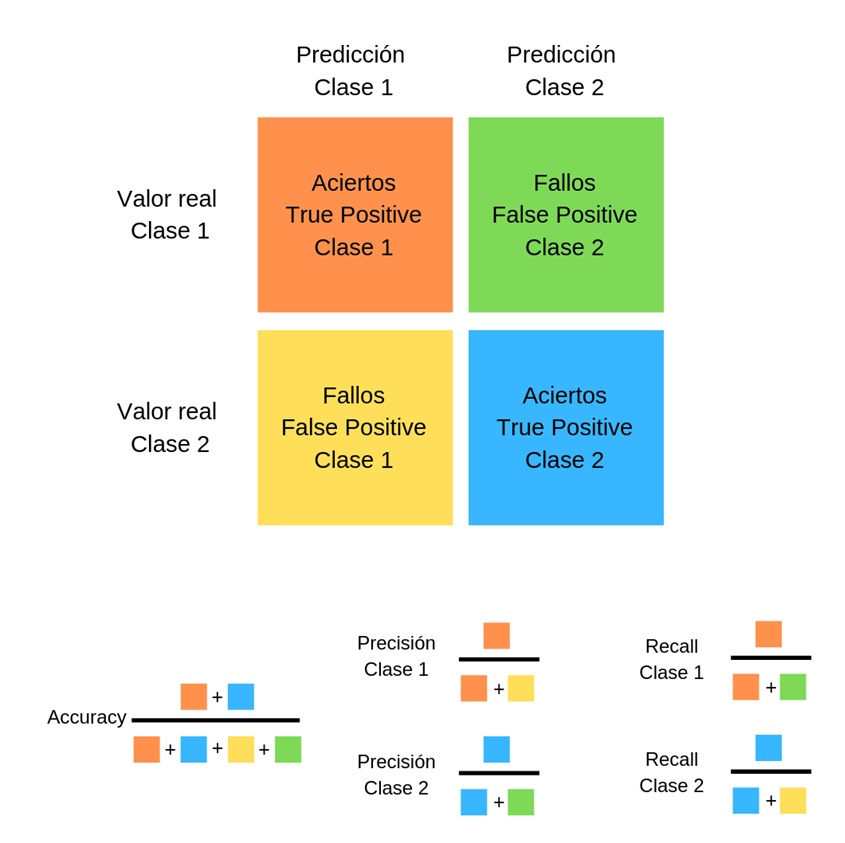

#Overfitting

El sobreajuste o "overfitting" en inglés, es un problema común en el aprendizaje automático. Ocurre cuando el modelo aprende demasiado bien los datos de entrenamiento, hasta el punto de memorizarlos, pero no logra generalizar a nuevos datos que no ha visto antes. En otras palabras, el modelo se ajusta demasiado a los datos de entrenamiento y pierde la capacidad de hacer predicciones precisas en datos que no ha visto antes.

El sobreajuste suele ocurrir cuando el modelo es demasiado complejo en relación al tamaño del conjunto de datos de entrenamiento, lo que significa que tiene demasiados parámetros o características. En este caso, el modelo puede aprender patrones irrelevantes en los datos de entrenamiento, en lugar de patrones que son verdaderamente importantes y generalizables.

Una forma de detectar el sobreajuste es observar el rendimiento del modelo en los datos de entrenamiento y los datos de prueba. Si el modelo tiene un rendimiento muy alto en los datos de entrenamiento pero un rendimiento mucho peor en los datos de prueba, es probable que esté sobreajustando. En este caso, puede ser necesario reducir la complejidad del modelo, aumentar la cantidad de datos de entrenamiento o aplicar técnicas de regularización para evitar el sobreajuste.

In [ ]:
# Entrenamiento y evaluación de Regresión Logística
lr_model = LogisticRegression(max_iter=10000)
train_evaluate_model( X_train, X_test,y_train, y_test,lr_model)

Train Accuracy: 0.7788, Precision: 0.0000, Recall: 0.0000, Specificity: 1.0000, AUC: 0.6468, Gini: 0.2936
Test Accuracy: 0.7788, Precision: 0.0000, Recall: 0.0000, Specificity: 1.0000, AUC: 0.6322, Gini: 0.2644


In [ ]:
# Entrenamiento y evaluación de Árbol de decisión
dt_model = DecisionTreeClassifier(random_state=42 )
train_evaluate_model( X_train, X_test,y_train, y_test,dt_model)

Train Accuracy: 0.9995, Precision: 0.9998, Recall: 0.9977, Specificity: 0.9999, AUC: 1.0000, Gini: 1.0000
Test Accuracy: 0.7145, Precision: 0.3694, Recall: 0.4115, Specificity: 0.8006, AUC: 0.6075, Gini: 0.2149


In [ ]:
# Entrenamiento y evaluación de Random Forest
rf_model = RandomForestClassifier(random_state=42)
train_evaluate_model( X_train, X_test,y_train, y_test,rf_model)

Train Accuracy: 0.9995, Precision: 0.9991, Recall: 0.9985, Specificity: 0.9997, AUC: 1.0000, Gini: 1.0000
Test Accuracy: 0.8120, Precision: 0.6325, Recall: 0.3580, Specificity: 0.9409, AUC: 0.7506, Gini: 0.5012


In [ ]:
# Entrenamiento y evaluación de LGBM
lgbm_model = LGBMClassifier(random_state=42)
train_evaluate_model( X_train, X_test,y_train, y_test,lgbm_model)

Train Accuracy: 0.8435, Precision: 0.7679, Recall: 0.4195, Specificity: 0.9640, AUC: 0.8833, Gini: 0.7666
Test Accuracy: 0.8187, Precision: 0.6671, Recall: 0.3595, Specificity: 0.9491, AUC: 0.7791, Gini: 0.5581


In [ ]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, classes, normalize=False, cmap=plt.cm.Blues):
    """
    Esta función grafica una matriz de confusión.

    :param y_true: array de numpy, valores reales de la variable objetivo
    :param y_pred: array de numpy, valores predichos por el modelo
    :param classes: array de numpy, etiquetas de las clases
    :param normalize: booleano, indica si se debe normalizar la matriz (es decir, si los valores deben expresarse como porcentajes).
    :param cmap: objeto colormap de matplotlib
    """

    # Calcula la matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    # Normaliza la matriz de confusión si se especifica
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Crea la figura y los ejes para el gráfico
    fig, ax = plt.subplots(figsize=(8, 6))

    # Grafica la matriz de confusión
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)

    # Añade la barra de colores
    plt.colorbar(im)

    # Añade las etiquetas de los ejes x e y
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes,
           yticklabels=classes,
           ylabel='Valor real',
           xlabel='Valor predicho')

    # Rota los ejes x e y si hay muchas clases
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Añade los valores de la matriz en cada celda
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    # Ajusta los límites del gráfico
    plt.tight_layout()

    # Muestra el gráfico
    plt.show()

In [ ]:
def evaluate_model(model, X_test, y_test, classes=['Negative', 'Positive'], cutoff=0.5):
    # Obtener las probabilidades de cada clase
    y_prob = model.predict_proba(X_test)[:, 1]

    # Aplicar el punto de corte para obtener las predicciones
    y_pred = (y_prob >= cutoff).astype(int)

    # Generar matriz de confusión
    plot_confusion_matrix(y_test, y_pred, classes)

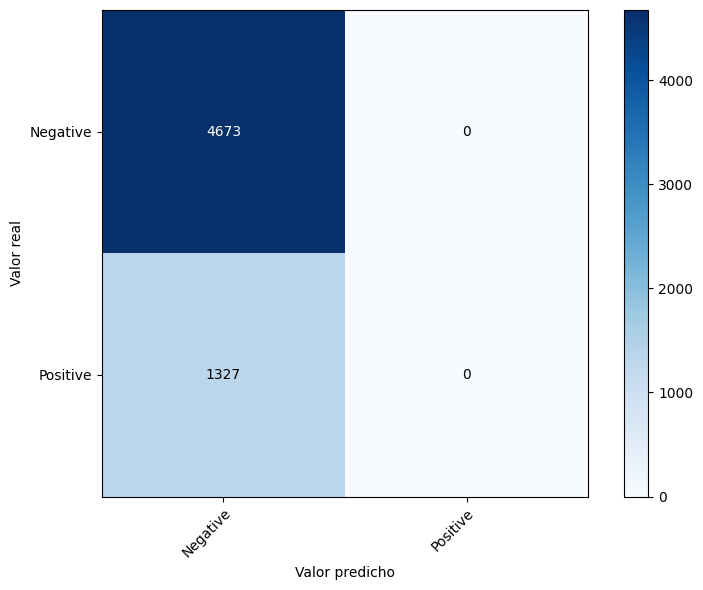

In [ ]:
evaluate_model(lr_model,X_test,y_test)

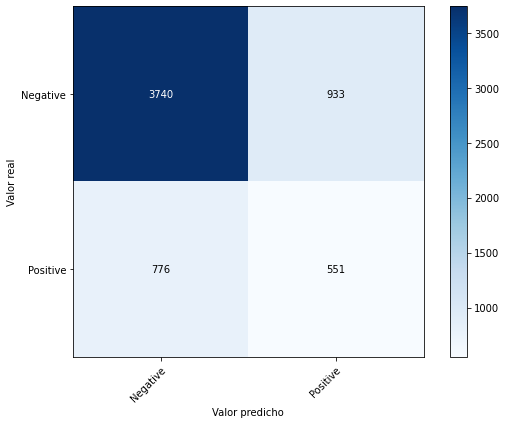

In [ ]:
evaluate_model(dt_model,X_test,y_test)

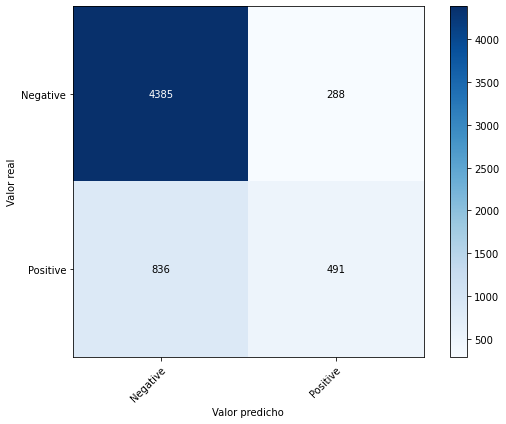

In [ ]:
evaluate_model(rf_model,X_test,y_test)

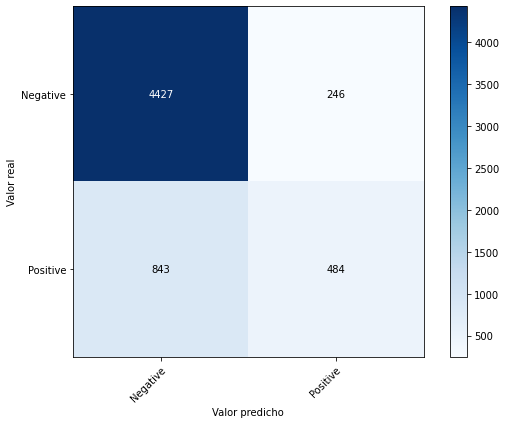

In [ ]:
evaluate_model(lgbm_model,X_test,y_test)